<a href="https://colab.research.google.com/github/DavidSenseman/BIO1173/blob/main/Assignment_02_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- BIO1173_ASSIGNMENT_02:Rev 1 -->

---------------------------
**COPYRIGHT NOTICE:** This Jupyterlab Notebook is a Derivative work of [Jeff Heaton](https://github.com/jeffheaton) licensed under the Apache License, Version 2.0 (the "License"); You may not use this file except in compliance with the License. You may obtain a copy of the License at

> [http://www.apache.org/licenses/LICENSE-2.0](http://www.apache.org/licenses/LICENSE-2.0)

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

------------------------

# **BIO 1173: Intro Computational Biology**

**Assignment_02: Convolutional Neural Networks (CNN) for Computer Vision**

* Instructor: [David Senseman](mailto:David.Senseman@utsa.edu), [Department of Integrative Biology](https://sciences.utsa.edu/integrative-biology/), [UTSA](https://www.utsa.edu/)



### Change your Runtime Now

Before you can begin, you will need to change your Runtime from CPU to a GPU. This assignment has been validated to run on the 'L4` and the `A100` GPUs, but other GPUs may work equally well.

## **READ CAREFULLY**

The **_second_**  digit in your myUTSA ID (e.g. "abc123") will determine which dataset you are to analyze for this assignment. For example, if your myUTSA ID was **vue682**, then your second digit is the number `8`.

**---WARNING------WARNING------WARNING------WARNING------WARNING------WARNING---**

You are **not** free to choose any dataset for this assignment. If analyze the wrong dataset, your assignment will **NOT BE GRADED** and you will receive a `0`.

If you are uncertain which dataset you should be working on, contact your Instructor for help. Remember, your score in this assignment will have a large impact on your course grade so please be careful.


| **2nd Digit myUTSA ID** | **Dataset to Analyze**  | **Datafile Name**
--------------------------|-------------------------|-----------------
0                         | DermaMNIST              | dermamnist_64.npz
1                         | OCTMNIST                | octmnist.npz
2                         | PneumoniaMNIST          | pneumoniamnist_64.npz
3                         | BreastMNIST             | breastmnist_224.npz
4                         | PathMNIST               | pathmnist_128.npz
5                         | BloodMNIST              | bloodmnist_128.npz
6                         | TissueMNIST             | tissuemnist.npz
7                         | OrganMNIST - A          | organamnist.npz
8                         | OrganMNIST - C          | organcmnist.npz
9                         | OrganMNIST - S          | organsmnist.npz

# **The Purpose of Assignments**

In this course, **_Assignments_** are designed to help me (and you) assess your ability to transfer knowledge gained in completing class coding exercises to solving more realistic problems.

Assignments play a pivotal role in reinforcing your learning, as they require you to apply theoretical concepts to practical scenarios. This helps solidify your understanding and enhances your problem-solving skills. By tackling these assignments independently, you develop critical thinking and the ability to synthesize information from various sources. Moreover, assignments encourage you to explore topics more deeply, fostering intellectual curiosity and promoting a deeper engagement with the subject matter. Ultimately, these assignments are not just a measure of your learning, but a means to equip you with the skills needed for real-world applications and future challenges.

## Google CoLab Instructions

Run next code cell to map this Colab lesson's folder /content/drive to your Google Drive. This will allow you keep a copy of your work in case you need it later.

In [ ]:
# @title **Run this cell first**
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    from google.colab import auth
    auth.authenticate_user()
    COLAB = True
    print("Note: Using Google CoLab")
    !curl ipinfo.io
except:
    print("**WARNING**: Your GMAIL address was **not** printed in the output below.")
    print("**WARNING**: You will NOT receive credit for this lesson.")
    COLAB = False

Mounted at /content/drive
Note: Using Google CoLab
{
  "ip": "35.187.236.73",
  "hostname": "73.236.187.35.bc.googleusercontent.com",
  "city": "Singapore",
  "region": "Singapore",
  "country": "SG",
  "loc": "1.2897,103.8501",
  "org": "AS396982 Google LLC",
  "postal": "018989",
  "timezone": "Asia/Singapore",
  "readme": "https://ipinfo.io/missingauth"
}

## Accelerated Run-time Check

The code in this cell checks what hardware acceleration you are using. To run this lesson, you must be running a Graphics Processing Unit (GPU). This lesson has been validated using both the `L4` and the `A100` GPUs but other hardware assisted environments should also work.

In [ ]:
# @title **Run this cell second**

import torch

# Check for GPU
def check_colab_gpu():
    print("=== Colab GPU Check ===")

    # Check PyTorch
    pt_gpu = torch.cuda.is_available()
    print(f"PyTorch GPU available: {pt_gpu}")

    if pt_gpu:
        print(f"PyTorch device count: {torch.cuda.device_count()}")
        print(f"PyTorch current device: {torch.cuda.current_device()}")
        print(f"PyTorch device name: {torch.cuda.get_device_name()}")
        print("You are good to go!")

    else:
        print("No compatible device found")
        print("WARNING: You must run this assigment using either a GPU to earn credit")
        print("Change your RUNTIME now and start over!")

check_colab_gpu()

=== Colab GPU Check ===
PyTorch GPU available: True
PyTorch device count: 1
PyTorch current device: 0
PyTorch device name: NVIDIA L4
You are good to go!


You should see something _similar_ to the following output:
```text
=== Colab GPU Check ===
PyTorch GPU available: True
PyTorch device count: 1
PyTorch current device: 0
PyTorch device name: NVIDIA L4
You are good to go!
```

In order for your assignment to be graded, the output from the last code cell should say either "Running on GPU" or "Running on TPU".

# **Assignment_02: Convolutional Neural Networks (CNN) for Computer Vision**

**Assignment_02** is specifically designed to assess your ability to write the PyTorch code necessary to build neural networks that can analyze medical images using a Convolutional Neural Network (CNN).

This assignment is divided into steps to make coding (and grading) easier. You should `Class_03_1` for all of your code examples. The steps in this assignment correspond to the same steps as those in `Class_03_1`.  


# **Descriptions of Data Sets for Assignment_02**

This section describes the various Medical MNIST datasets that will be used for this assignment.


-----------------------------


### **DermaMNIST - 2nd myUTSA Digit = 0**

##### **Filename:** `dermamnist_64.npz`

**DermaMNIST** is a medical imaging dataset containing 7,000 images of skin lesions, each with a resolution of 64x64 pixels. It is designed for dermatological image classification and is based on the HAM10000 dataset, which includes multi-source dermatoscopic images of common pigmented skin lesions. The dataset is structured as a multi-class classification task, categorizing images into seven different skin conditions, including melanoma, basal cell carcinoma, and benign keratosis-like lesions


------------------------------------------

### **OCTMNIST Dataset - 2nd myUTSA Digit = 1**

##### **Filename:** `octmnist.npz`

**OCTMNIST** is a medical imaging dataset containing **109,309 optical coherence tomography (OCT) images**, designed for retinal disease classification. The dataset consists of four diagnosis categories, making it a multi-class classification task. The images are grayscale and originally vary in size between (384–1,536)x(277–512) pixels, but they have now been center-cropped and resized to 28x28 pixels for standardization.


-----------------------------------------

### **PneumoniaMNIST Dataset - 2nd myUTSA Digit = 2**

##### **Filename:** `pneumoniamnist_64.npz`

**PneumoniaMNIST** is a medical imaging dataset containing **5,856 pediatric chest X-ray images**, designed for binary classification of pneumonia versus normal cases. The dataset is derived from a prior collection of chest X-rays and has been preprocessed to standardize image sizes. The original images vary in resolution between (384–2,916)×(127–2,713) pixels, but they are now center-cropped and resized to 28×28 pixels for consistency


-----------------------------------

-----------------------------

### **BreastMNIST - 2nd myUTSA Digit = 3**

##### **Filename:** `breastmnist_224.npz`

**BreastMNIST** is a medical imaging dataset that is part of the MedMNIST collection, designed for breast cancer classification using **10,239 mammography images**. The dataset consists of two classes: benign and malignant, making it a binary classification task. The images are preprocessed and standardized to a resolution of 224x224 pixels, ensuring consistency for deep learning applications.

------------------------------------------

### **PathMNIST Dataset - 2nd myUTSA Digit = 4**

##### **Filename:** `pathmnist_128.npz`

**PathMNIST** is a medical imaging dataset derived from **colorectal cancer histology slides**. It consists of 100,000 non-overlapping image patches from hematoxylin & eosin-stained histological images, with an additional 7,180 image patches from a separate clinical center for testing. The dataset is structured as a multi-class classification task, categorizing images into nine different tissue types, including adipose, lymphocytes, mucus, smooth muscle, normal colon mucosa, cancer-associated stroma, and colorectal adenocarcinoma epithelium

-----------------------------------------

### **PneumoniaMNIST Dataset - 2nd myUTSA Digit = 5**

##### **Filename:** `pneumoniamnist_64.npz`

**BloodMNIST** is a medical imaging dataset containing **17,092 images of blood samples**, categorized into eight different classes. The dataset is designed for hematology-related classification tasks, helping researchers develop AI models for blood cell analysis. The images were originally 3x360x363 pixels, but they have been center-cropped to 3x200x200 pixels and then resized to 3x28x28 pixels for standardization


-----------------------------------

-----------------------------


### **TissueMNIST - 2nd myUTSA Digit = 6**

##### **Filename:** `tissuemnist.npz`

**TissueMNIST** is a medical imaging dataset derived from BBBC051, a collection of **human kidney cortex cell images** from the Broad Bioimage Benchmark Collection. It contains 236,386 grayscale images of segmented kidney cells, categorized into eight different tissue types, including collecting ducts, glomerular endothelial cells, leukocytes, and proximal tubule segments.

Each image originally has 32x32x7 pixels, where 7 represents different slices of the same tissue sample. To standardize the dataset, the maximum pixel values across slices are taken, and the images are resized to 28x28 pixels

------------------------------------------

### **OrganMNIST-A Dataset - 2nd myUTSA Digit = 7**

##### **Filename:** `organamnist.npz`

**OrganMNIST-A**, the "A" stands for "Axial", referring to the axial view of medical imaging scans. OrganMNIST-A is derived from **full-body CT scans**, and it specifically contains axial slices of different organs, making it a structured dataset for organ classification tasks.


------------------------------------------

### **OrganMNIST-C Dataset - 2nd myUTSA Digit = 8**

##### **Filename:** `organcmnist.npz`

**OrganMNIST-C**, the "C" stands for "Coronal", referring to the coronal view of medical imaging scans. OrganMNIST-C is derived from **full-body CT scans**, and it specifically contains coronal slices of different organs, making it a structured dataset for organ classification tasks.


------------------------------------------

### **OrganMNIST-S Dataset - 2nd myUTSA Digit = 9**

##### **Filename:** `organsmnist.npz`

**OrganAMNIST**, the "S" stands for "Sagittal", referring to the saggital view of medical imaging scans. OrganAMNIST is derived from **full-body CT scans**, and it specifically contains sagittal slices of different organs, making it a structured dataset for organ classification tasks.



-----------------------------------------------------
# **General Instructions**

To make the assignment more manageable, you will given a number of specific steps to perform. These steps correspond to the steps used for the example (and the exercise) in `Class_03_1`.

### **You Must Download Your Dataset from the Course File Server**

You can only download your assigned dataset from the Course File server even if you happen to find a dataset with exactly the same name somewhere else. If you download your data from a different file server, your assignment will not be graded and you will recieve a score of 1 point.

### **You Can _NOT_ Use AI**

You can **not** use AI for this assignment. If you use AI, your assignment will not be graded and you will recieve a score of 1 point.

## Create Functions for this Assignment

Run the next code to create functions that you will need to complete this assignment.

In [ ]:
# @title Create functions for this lesson
import psutil
import os

def check_current_ram():
  ram = psutil.virtual_memory()
  print(f"Available RAM: {ram.available / (1024 ** 3):.2f} GB")

def list_files():
   files = os.listdir('.')
   print(f"Current files: {files}")

def list_extract():
  files = os.listdir(EXTRACT_TARGET)
  print(f"Current files in EXTRACT_TARGET: {files}")

# Simple function to print out elasped time
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return "{}:{:>02}:{:>05.2f}".format(h, m, s)

# Set random seed
def set_seed():
    """
    Sets the seed for reproducibility across Python, NumPy, and PyTorch.
    """
    import random

    # Set seed value
    seed_value=1173

    # 1. Base Python
    random.seed(seed_value)

    # 2. NumPy
    np.random.seed(seed_value)

    # 3. PyTorch (CPU and CUDA)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value) # For multi-GPU setups

    # 4. CuDNN Determinism (Crucial for GPU consistency)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 5. Ensure all operations are deterministic
    torch.use_deterministic_algorithms(True)
    print("The seed is set ✅ \n")

print("✅ All custom functions have been created.")

✅ All custom functions have been created.


## **Step 1: Setup Evironmental Variables**

In the cell below, create environmental variables so you can download your specific MedMNIST dataset that has been assigned to you. If you don't use the code provided in Class_03_1 as a template, you will make an unacceptable number of coding errors.

If you use the code from Step 1 in Class_03_1, you will only need to make changes to the `DOWNLOAD_SOURCE` and the `EXTRACT_TARGET`.

For your `EXTRACT_TARGET` you should use the file name of the MedMNIST assigned to you in the cell above, **exactly** as it is written.

For example, if the 2nd digit of your myUTSA ID was `0`, your `DOWNLOAD_SOURCE` would be:
~~~text
DOWNLOAD_SOURCE = URL+"/dermamnist_64.npz"
~~~
and your `EXTRACT_TARGET` would be:
~~~text
EXTRACT_TARGET = os.path.join(PATH,"dermamnist_64")
~~~

Be careful when you cut-and-paste that you don't accidently include any spaces.


In [ ]:
# @title Step 1: Setup Environmental Variables

import os

# Define datafile location
URL = "https://biologicslab.co/BIO1173/data"
DOWNLOAD_SOURCE = URL+"/dermamnist_64.npz"
DOWNLOAD_NAME = DOWNLOAD_SOURCE[DOWNLOAD_SOURCE.rfind('/')+1:]
print(f"DOWNLOAD_SOURCE {DOWNLOAD_SOURCE}")
print(f"DOWNLOAD_NAME {DOWNLOAD_NAME}")

# Define folder locations to store the data
PATH = "/content"
EXTRACT_TARGET = os.path.join(PATH,"/dermamnist_64")
SOURCE = os.path.join(EXTRACT_TARGET)
TARGET = SOURCE

# Print out environmental variables
print(f"PATH {PATH}")
print(f"EXTRACT_TARGET {EXTRACT_TARGET}")
print(f"SOURCE {SOURCE}")
print(f"TARGET {TARGET}")

DOWNLOAD_SOURCE https://biologicslab.co/BIO1173/data/dermamnist_64.npz
DOWNLOAD_NAME dermamnist_64.npz
PATH /content
EXTRACT_TARGET /dermamnist_64
SOURCE /dermamnist_64
TARGET /dermamnist_64


## **Step 2: Download and Extract Data**

If your code in Step-1: is correct, you should be ready to download and extract your dataset.

In the cell below, write the code to (1) download your datafile, (2) make the appropiate file folders and (3) extract (unzip) your data into the file folders you created.


In [ ]:
# @title Step 2: Download and Extract Data
import os

print("Creating necessary directories...", end='')
# Create necessary directories
os.makedirs(SOURCE, exist_ok=True)
os.makedirs(EXTRACT_TARGET, exist_ok=True)
print("done.")

print("Downloading files...", end='')
# Define paths and URLs
download_path = os.path.join(PATH, DOWNLOAD_NAME)
extract_path = os.path.join(EXTRACT_TARGET, DOWNLOAD_NAME)

# Download the file
os.system(f"wget -O {download_path} {DOWNLOAD_SOURCE}")
print("done.")

print("Extracting files...", end='')
# Extract the file
os.system(f"unzip -o -d {EXTRACT_TARGET} {download_path} >/dev/null")
print("done.")

Creating necessary directories...done.
Extracting files...done.


## **Step 3: Load and Shuffle Images and Labels into Numpy Arrays**

In the cell below, write the Python code to read (load) and shuffle the image and label data into Numpy arrays. In total, you should create the following 6 numpy arrays: `train_X`, `train_Y`, `test_X`, `test_Y`, `val_X` and `val_Y`. The `X` arrays will have the images, the `Y` arrays will have their corresponding labels.

Make sure to print out the `shape` of each numpy array.  

In [ ]:
# @title Step 3: Load and Shuffle Images and Labels into Numpy Arrays

import numpy as np

# Set the seed
set_seed()

# ------------------------------------------------------------------------
# 1️⃣  Unpack and shuffle train images
# ------------------------------------------------------------------------
train_images = np.load(os.path.join(SOURCE,"train_images.npy"),)
train_labels = np.load(os.path.join(SOURCE,"train_labels.npy"),)
combined = list(zip(train_images, train_labels))
np.random.shuffle(combined)
X_train, y_train = zip(*combined)
X_train = np.array(X_train)
y_train = np.array(y_train)
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

# ------------------------------------------------------------------------
# 2️⃣  Unpack and shuffle test images
# ------------------------------------------------------------------------
test_images = np.load(os.path.join(SOURCE,"test_images.npy"),)
test_labels = np.load(os.path.join(SOURCE,"test_labels.npy"),)
combined = list(zip(test_images, test_labels))
np.random.shuffle(combined)
X_test, y_test = zip(*combined)
X_test = np.array(X_test)
y_test = np.array(y_test)
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

# ------------------------------------------------------------------------
# 3️⃣  Unpack and shuffle validation images
# ------------------------------------------------------------------------
# Unpack and shuffle val_images
val_images = np.load(os.path.join(SOURCE,"val_images.npy"),)
val_labels = np.load(os.path.join(SOURCE,"val_labels.npy"),)
combined = list(zip(val_images, val_labels))
np.random.shuffle(combined)
X_val, y_val = zip(*combined)
X_val = np.array(X_val)
y_val = np.array(y_val)
print(f"X_val: {X_val.shape}")
print(f"y_val: {y_val.shape}")

The seed is set ✅ 

X_train: (7007, 64, 64, 3)
y_train: (7007, 1)
X_test: (2005, 64, 64, 3)
y_test: (2005, 1)
X_val: (1003, 64, 64, 3)
y_val: (1003, 1)


## **Step 4: Add Color Channel and Resize Images**

Write the code needed to convert all of your images into color (RGB) and resize them to be 128 X 128 pixels.

In [ ]:
# @title Step 4: Add Color Channel and Resize Images

import numpy as np
import tensorflow as tf

# ------------------------------------------------------------------------
# 1️⃣  Add color channels to make it 3-channel (RGB)
# ------------------------------------------------------------------------
# Check if images are grayscale (3 dimensions: N, H, W)
if X_train.ndim == 3:
    print("Adding channel dimension...", end='')
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)
    X_val = np.expand_dims(X_val, axis=-1)
    print("done")

# Check if images have 1 channel (N, H, W, 1) and need to be 3 (N, H, W, 3)
if X_train.shape[-1] == 1:
    print("Converting 1-channel Grayscale to 3-channel RGB...", end='')
    # Repeat the single channel 3 times along the last axis
    X_train = np.repeat(X_train, 3, axis=-1)
    X_test = np.repeat(X_test, 3, axis=-1)
    X_val = np.repeat(X_val, 3, axis=-1)
    print("done")
else:
    print("Images are already 3-channel RGB")

# ------------------------------------------------------------------------
# 2️⃣  Resize images to standard 128x128 pixels
# ------------------------------------------------------------------------
TARGET_SIZE = 128

if X_train.shape[1] == TARGET_SIZE and X_train.shape[2] == TARGET_SIZE:
    print(f"No need to resize images--already {TARGET_SIZE}x{TARGET_SIZE} pixels.")
    X_train_resized = X_train
    X_test_resized = X_test
    X_val_resized = X_val
else:
    print(f"Resizing images to {TARGET_SIZE}x{TARGET_SIZE} pixels...", end='')
    X_train_resized = np.array([tf.image.resize(img, (TARGET_SIZE, TARGET_SIZE)).numpy() for img in X_train])
    X_test_resized = np.array([tf.image.resize(img, (TARGET_SIZE, TARGET_SIZE)).numpy() for img in X_test])
    X_val_resized = np.array([tf.image.resize(img, (TARGET_SIZE, TARGET_SIZE)).numpy() for img in X_val])
    print("done")

# ------------------------------------------------------------------------
# 3️⃣  Copy back
# ------------------------------------------------------------------------
X_train = np.copy(X_train_resized)
X_test = np.copy(X_test_resized)
X_val = np.copy(X_val_resized)

# ------------------------------------------------------------------------
# 4️⃣   Check shapes
# ------------------------------------------------------------------------
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Val shape:   {X_val.shape}")



Images are already 3-channel RGB
Resizing images to 128x128 pixels...done
Train shape: (7007, 128, 128, 3)
Test shape:  (2005, 128, 128, 3)
Val shape:   (1003, 128, 128, 3)


## **Step 5: Check Available Memory**

Write the code to check your available memory. Print your total memory, the available memory and the used memory.

In [ ]:
# @title Step 5: Check Available Memory

import psutil

# Get the memory details
mem = psutil.virtual_memory()

# Print total, available, and used memory
print(f"Total Memory: {mem.total / (1024 ** 3):.2f} GB")
print(f"Available Memory: {mem.available / (1024 ** 3):.2f} GB")
print(f"Used Memory: {mem.used / (1024 ** 3):.2f} GB")



Total Memory: 52.96 GB
Available Memory: 45.96 GB
Used Memory: 6.37 GB


## **Step 6: Augment Training Image Set**

Augment your image dataset by flipping them both horizontally and vertically. Don't forget to set the seed.

In [ ]:
# @title Step 6: Augment Training Image Set

import psutil

# Set the seed
set_seed()

# ------------------------------------------------------------------------
# 1️⃣  Get the memory details
# ------------------------------------------------------------------------
mem = psutil.virtual_memory()

# ------------------------------------------------------------------------
# 2️⃣  Augment if available memory is sufficient
# ------------------------------------------------------------------------
if mem.available <= mem.used:
    print(f"Available memory ({mem.available / (1024 ** 3):.2f} GB) might not be enough to augment X_train")
    print(f"Number of X_train images: {X_train.shape[0]}")
else:
    print(f"Available memory ({mem.available / (1024 ** 3):.2f} GB) should be enough to augment X_train")
    print("Augmenting the number of images in X_train...", end=' ')

    # Initialize lists to store the augmented images and labels
    augmented_images = []
    augmented_labels = []

    # Iterate through each image and its corresponding label
    for img, label in zip(X_train, y_train):
        # Original image
        augmented_images.append(img)
        augmented_labels.append(label)

        # Vertically flipped image
        augmented_images.append(np.flipud(img))
        augmented_labels.append(label)

        # Horizontally flipped image
        augmented_images.append(np.fliplr(img))
        augmented_labels.append(label)

    # Convert lists back to numpy arrays
    augmented_images = np.array(augmented_images)
    augmented_labels = np.array(augmented_labels)

    print("done")
    print(f"Original number of X_train images: {len(X_train)}")
    print(f"Augmented number of X_train images: {len(augmented_images)}")

    # Copy images back
    X_train = np.copy(augmented_images)
    y_train = np.copy(augmented_labels)


The seed is set ✅ 

Available memory (46.06 GB) should be enough to augment X_train
Augmenting the number of images in X_train... done
Original number of X_train images: 7007
Augmented number of X_train images: 21021


## **Step 7: Construct CNN Model**

In the cell below write the PyTorch code to build a CNN model to analyze your image data. Make sure that your `input_dim` matches your image size.

Your CNN must be exactly equivalent to the example model in `Class_03_1`.

In [ ]:
# @title Step 7: Construct CNN model

# ------------------------------------------------------------------------
# 0️⃣  Load packages
# ------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

# Set the seed
set_seed()

# ------------------------------------------------------------------------
# 1️⃣  Define variables
# ------------------------------------------------------------------------
# Define input_dim: UPDATED for 128x128 images
input_dim = (128, 128, 3)

# Set learning rate
learning_rate = 0.001

# Set patience
PATIENCE = 10

# ------------------------------------------------------------------------
# 2️⃣  Create CNN model using PyTorch nn.Module
# ------------------------------------------------------------------------
class CNNModel(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super(CNNModel, self).__init__()

        # 1st Convolution layer (Input 128x128) -> Output 64x64 after Pool
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        # 2nd Convolution layer (Input 64x64) -> Output 32x32 after Pool
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(32)

        # 3rd Convolution layer (Input 32x32) -> Output 16x16 after Pool
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        # 4th Convolution layer (Input 16x16) -> Output 8x8 after Pool
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(128)

        # Dropout layers
        self.dropout1 = nn.Dropout2d(dropout_rate)
        self.dropout2 = nn.Dropout2d(dropout_rate)
        self.dropout3 = nn.Dropout2d(dropout_rate)
        self.dropout4 = nn.Dropout(dropout_rate)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.bn5 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # 1st Convolution block
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = self.bn1(x)

        # 2nd Convolution block
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)
        x = self.bn2(x)
        x = self.dropout1(x)

        # 3rd Convolution block
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2, 2)
        x = self.bn3(x)
        x = self.dropout2(x)

        # 4th Convolution block
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2, 2)
        x = self.bn4(x)
        x = self.dropout3(x)

        # Flatten
        x = x.view(x.size(0), -1)  # Flatten for dense layers

        # Dense layers
        x = F.relu(self.fc1(x))
        x = self.bn5(x)
        x = self.dropout4(x)

        # Output layer
        x = self.fc2(x)

        return x

# ------------------------------------------------------------------------
# 3️⃣  Determine the number of classes
# ------------------------------------------------------------------------
# Get unique classes from training labels (assuming they are class indices now)
unique_classes = np.unique(y_train)
class_count = len(unique_classes)

# ------------------------------------------------------------------------
# 4️⃣  Create the model instance
# ------------------------------------------------------------------------
model = CNNModel(num_classes=class_count)

# ------------------------------------------------------------------------
# 5️⃣  Define optimizer and loss function
# ------------------------------------------------------------------------
# L2 regularization via weight decay in optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.01)

# Use categorical crossentropy loss
criterion = nn.CrossEntropyLoss()

# Print number of classes to be used
print(f"The number of output classes =", class_count)

# Print model architecture
print("Model Architecture:")
print(model)

# Print model parameters count
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# ------------------------------------------------------------------------
# 5️⃣  Create EarlyStopping class
# ------------------------------------------------------------------------

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-3, verbose=False):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.val_loss_min = float('inf')

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss < self.best_loss - self.min_delta:
            # Loss improved significantly
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0
        else:
            # Loss did not improve enough
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f'Early stopping triggered after {self.patience} epochs without improvement')
                return True
        return False

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases'''
        if self.verbose and val_loss < self.val_loss_min:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
            # Save the model state (optional, for teaching we just print)
            self.val_loss_min = val_loss




The seed is set ✅ 

The number of output classes = 7
Model Architecture:
CNNModel(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout2d(p=0.5, inplace=False)
  (dropout2): Dropout2d(p=0.5, inplace=False)
  (dropout3): Dropout2d(p=0.5, inplace=False)
  (dropout4): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_fea

## **Step 8: Train the Neural Network**

Train your CNN. Make sure that you use these hyperparameters:
```text
EPOCHS = 100
BATCH_SIZE = 64
VERBOSE = 0  
PATIENCE = 10
```

In [ ]:
# @title Step 8: Train the Neural Network

import time
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# Set the seed
set_seed()

# ------------------------------------------------------------------------
# 1️⃣  Set variables
# ------------------------------------------------------------------------
EPOCHS = 100
BATCH_SIZE = 64
VERBOSE = 0  # 0 means no output during training
PATIENCE = 10

# Ensure data is in correct format for PyTorch (NCHW)
if len(X_train.shape) == 4 and X_train.shape[-1] == 3:
    X_train = X_train.transpose(0, 3, 1, 2)
    X_val = X_val.transpose(0, 3, 1, 2)

# Squeeze the extra dimension from labels
y_train_squeezed = np.squeeze(y_train, axis=1)
y_val_squeezed = np.squeeze(y_val, axis=1)

# Create datasets
train_dataset = TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train_squeezed).long()
)
val_dataset = TensorDataset(
    torch.from_numpy(X_val).float(),
    torch.from_numpy(y_val_squeezed).long()
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Determine device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move model to device
model = model.to(device)

# ------------------------------------------------------------------------
# 2️⃣  Train model with Early Stopping
# ------------------------------------------------------------------------
print(f"----- Training is starting for {EPOCHS} epochs, batch size: {BATCH_SIZE} --------------")
# Record start time
start_time = time.time()

# Create early stopping instance
early_stopping = EarlyStopping(patience=PATIENCE, min_delta=1e-3, verbose=True)

# Initialize lists to store training history
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Training loop
best_val_acc = 0.0
best_epoch = 0
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        # Move data to device
        data, target = data.to(device), target.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(data)

        # Calculate loss
        loss = criterion(output, target)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0

    val_total = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)

            val_loss += loss.item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()

    # Calculate average losses
    avg_train_loss = train_loss/ len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = 100. * train_correct / train_total
    val_acc = 100. * val_correct / val_total

    # Save history
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Early stopping check
    early_stopping(avg_val_loss, model)

    # Print progress
    if VERBOSE >= 2:
        print(f'Epoch {epoch+1}/{EPOCHS} - '
              f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% - '
              f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    # Check if this is the best validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_val_loss = avg_val_loss

    # Early stopping condition
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch+1}")
        break

# ---------------------------------------------------------------------------
# 9️⃣ Inspect training
# ------------------------------------------------------------------------
print(f"\nTraining finished.")
print(f"Best val accuracy: {best_val_acc:.4f} (achieved at epoch {best_epoch})")
print(f"Best val loss: {best_val_loss:.4f}")

# Record end time
elapsed_time = time.time() - start_time

# Print elapsed time
print(f"Elapsed time: {hms_string(elapsed_time)}")

# Print final training statistics
print(f"Final training completed in {epoch+1} epochs")


The seed is set ✅ 

Using device: cuda
----- Training is starting for 100 epochs, batch size: 64 --------------
Validation loss decreased (inf --> 0.833178).  Saving model ...
Validation loss decreased (0.833178 --> 0.815317).  Saving model ...
Validation loss decreased (0.815317 --> 0.811887).  Saving model ...
Validation loss decreased (0.811887 --> 0.797522).  Saving model ...
Validation loss decreased (0.797522 --> 0.788362).  Saving model ...
Validation loss decreased (0.788362 --> 0.764351).  Saving model ...
Validation loss decreased (0.764351 --> 0.760333).  Saving model ...
Validation loss decreased (0.760333 --> 0.755987).  Saving model ...
Validation loss decreased (0.755987 --> 0.746580).  Saving model ...
Early stopping triggered after 10 epochs without improvement
Early stopping at epoch 32

Training finished.
Best val accuracy: 72.9811 (achieved at epoch 23)
Best val loss: 0.7481
Elapsed time: 0:02:48.70
Final training completed in 32 epochs


## **Step 9: Visualize Training**

Write the code to visualize what happened during the training of your CNN using two different graphs, side-by-side. The graph on the left should show changes in `Accuracy` of the training and validation data; The graph on the right should show changes in `Loss` for the training and valiadation data.

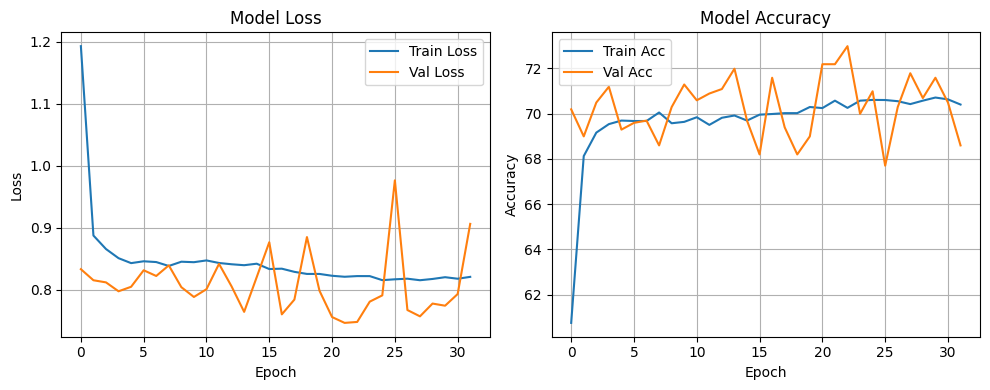

In [ ]:
# @title Step 9: Visualize Training

import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# ------------------------------------------------------------------
# Plot 1: Loss (Left Graph)    # Save history
# ------------------------------------------------------------------
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# ------------------------------------------------------------------
# Plot 2: Accuracy (Right Graph)
# ------------------------------------------------------------------
ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()



## **Step 10: Plot 4 Frames with Label**

Plot four images from your data set, making sure that you use a meaningful label. For example, if your datafile was `pathmnist_128`, you label might say `Organ type` or `Pathology type`. Do **not** use `Blood Cell type` unless you were asked analyze the bloodcell datafile, `bloodmnist_224`.


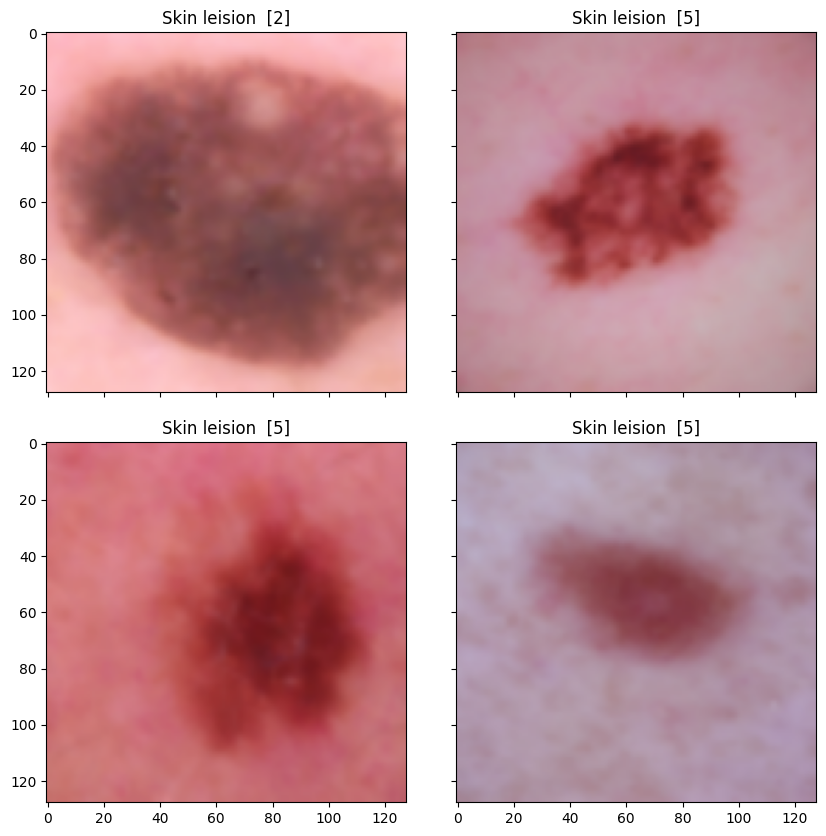

In [ ]:
# @title Step 10: Plot 4 Frames with Label

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid


# Set figure size
fig = plt.figure(figsize=(10,10))
grid = ImageGrid(
        fig, 111,
        nrows_ncols=(2,2),
        axes_pad=0.5
)

# Plot 4 images
for x in range(0,4):
    grid[x].set_title('Skin leision  ' + str(y_test[x]))
    # FIX: Cast to uint8 so matplotlib treats them as 0-255 integers
    grid[x].imshow(X_test[x].astype("uint8"))

plt.show()




## **Electronic Submission**

In BIO 1173, assignments are basically **coding exams**. You will not know what score you will receive for `Assignment_02` until **after** you submit.

#### **WARNING:** YOU CAN ONLY SUBMIT YOUR ASSIGNMENT ONCE!

Don't submit your Assignment_02 unless you are sure you are ready to have it graded. You will not be given a second chance to make any corrections.  

In [ ]:
# @title  Electronic Submission

import urllib.request
import ssl
import time

url = "https://biologicslab.co/BIO1173/backend_code/validate_assignment.py?v=" + str(time.time())

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

req = urllib.request.Request(
    url,
    headers={
        "Cache-Control": "no-cache, no-store, must-revalidate",
        "Pragma": "no-cache",
        "Expires": "0"
    }
)

with urllib.request.urlopen(req, context=ctx) as r:
    exec(r.read().decode("utf-8"))

main()